<a href="https://colab.research.google.com/github/zackives/upenn-cis5450-hw/blob/main/ARIMA_SARIMA_more.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Timeseries

Portions based on https://medium.com/@tirthamutha/time-series-forecasting-using-sarima-in-python-8b75cd3366f2 and https://www.statsmodels.org/dev/examples/notebooks/generated/statespace_sarimax_stata.html#ARIMA-Example-2:-Arima-with-additive-seasonal-effects.

In [3]:
!wget https://storage.googleapis.com/penn-cis5450/DailyDelhiClimate.csv

--2025-11-12 15:52:09--  https://storage.googleapis.com/penn-cis5450/DailyDelhiClimate.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.194.207, 142.251.10.207, 142.251.12.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.194.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85248 (83K) [text/csv]
Saving to: ‘DailyDelhiClimate.csv’

DailyDelhiClimate.c 100%[===================>]  83.25K   380KB/s    in 0.2s    

2025-11-12 15:52:10 (380 KB/s) - ‘DailyDelhiClimate.csv’ saved [85248/85248]



Rather than the daily Australian dataset, we'll use a Kaggle dataset about daily temperatures in Delhi.  We know temperatures should be correlated day-to-day and season-to-season -- with a 12 month gap between seasons.

https://www.kaggle.com/datasets/sukhmandeepsinghbrar/daily-delhi-climate

<Axes: xlabel='date'>

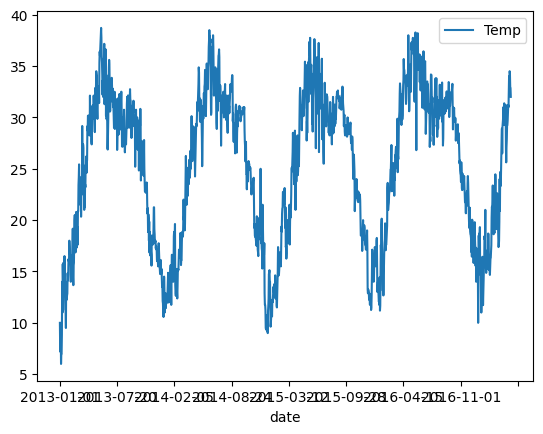

In [2]:
import pandas as pd

temps = pd.read_csv('DailyDelhiClimate.csv', header=0, index_col=0)

temps = temps[['Temp']]
temps.plot()

Let's look at the correlation between the lags and the data (autocorrelation) for a good region (more than a year)...

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

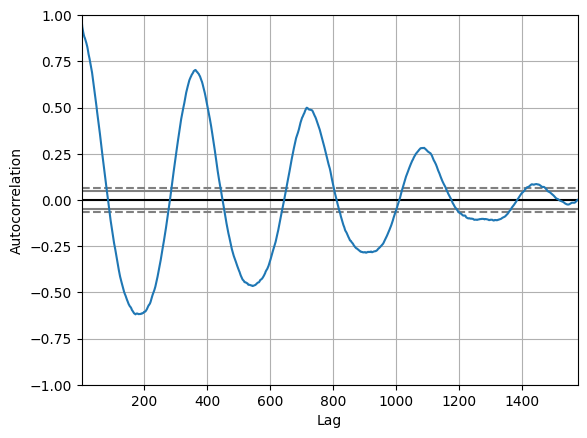

In [3]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(temps['Temp'])

And more locally as well...

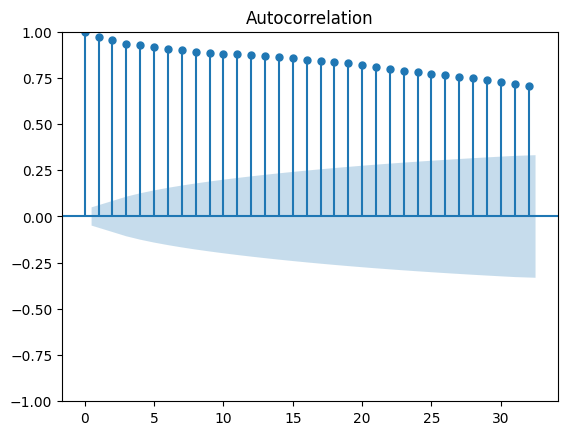

In [4]:
from statsmodels.graphics.tsaplots import plot_acf

_ = plot_acf(temps)

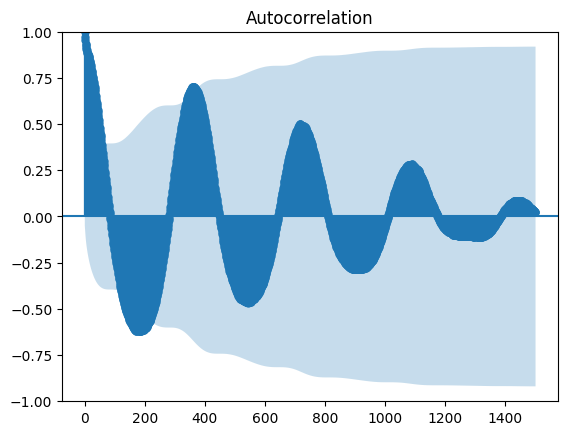

In [5]:
_ = plot_acf(temps, lags=1500)

Autocorrelation (as above) considers the correlation of the function's value with its distant previous values, indirectly considering all values in between. We can also look at *partial* autocorrelation, which is a direct correlation between the value and its past lag.

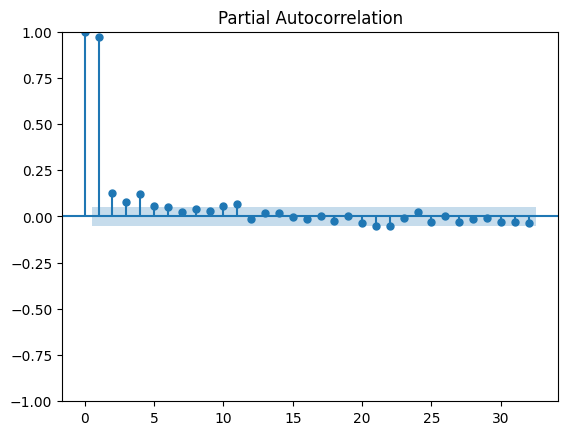

In [6]:
from statsmodels.graphics.tsaplots import plot_pacf

_ = plot_pacf(temps)

Here we can see that the 3rd lag, for instance, is less correlated than the 4th, 5th, etc.

## Takeaways So Far

We have both ARIMA (which follows *small, short-term seasonality within the lags*, as well as longer tremds) and SARIMA (which allows us to include a longer-term seasonal element).

The above plots let us understand how many lags make sense.  We can further fine-tune (p,d,q) for "local" and "seasonal" components with grid search -- but even basic values are likely to work well.

In [3]:
!pip install "numpy<2" pmdarima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 94.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.4
    Uninstalling numpy-2.3.4:
      Successfully uninstalled numpy-2.3.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatib

Restart the kernel as requested.

<Axes: xlabel='date'>

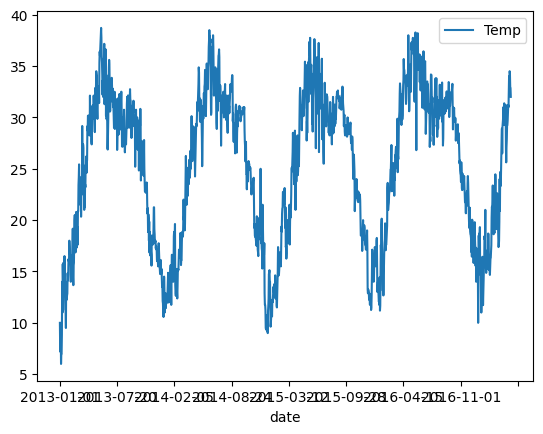

In [26]:
import pandas as pd

temps = pd.read_csv('DailyDelhiClimate.csv', header=0, index_col=0)

temps = temps[['Temp']]
temps.plot()

In [27]:
import warnings
warnings.filterwarnings('ignore')
import pmdarima as pmd
model = pmd.auto_arima(temps['Temp'],start_p=1,start_q=1,test='adf',m=12,seasonal=True,trace=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=5995.445, Time=5.60 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=6104.687, Time=0.08 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=6067.988, Time=0.74 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=6056.265, Time=0.98 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=6102.796, Time=0.12 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=5996.594, Time=6.67 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=5996.566, Time=3.08 sec
 ARIMA(1,1,1)(2,0,1)[12] intercept   : AIC=5996.702, Time=16.52 sec
 ARIMA(1,1,1)(1,0,2)[12] intercept   : AIC=5996.640, Time=21.02 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=5995.198, Time=1.18 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=6054.571, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=6066.213, Time=0.19 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=5997.066, Time=1.08 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : AIC=5997.088, Time=0.87 sec
 ARIMA(0,1,2)(0,0

In [28]:
temps2 = temps.copy()
temps2.index = pd.DatetimeIndex(temps.index).to_period('D')

In [29]:
temps2

,Temp
date,
2013-01-01,10.000000
2013-01-02,7.400000
2013-01-03,7.166667
2013-01-04,8.666667
2013-01-05,6.000000
...,...
2017-04-20,34.500000
2017-04-21,34.250000
2017-04-22,32.900000


In [30]:
import statsmodels.api as sm

sarima=sm.tsa.statespace.SARIMAX(temps2,order=(1,1,1),seasonal_order=(1,0,1,12))
predicted=sarima.fit().predict();

# Let's compare against a model without the Seasonal component
sarima=sm.tsa.statespace.SARIMAX(temps2,order=(1,1,1))
predicted2=sarima.fit().predict();

In [31]:
temps2.index

PeriodIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
             '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
             '2013-01-09', '2013-01-10',
             ...
             '2017-04-15', '2017-04-16', '2017-04-17', '2017-04-18',
             '2017-04-19', '2017-04-20', '2017-04-21', '2017-04-22',
             '2017-04-23', '2017-04-24'],
            dtype='period[D]', name='date', length=1576)

In [33]:
temps.index

Index(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04', '2013-01-05',
       '2013-01-06', '2013-01-07', '2013-01-08', '2013-01-09', '2013-01-10',
       ...
       '2017-04-15', '2017-04-16', '2017-04-17', '2017-04-18', '2017-04-19',
       '2017-04-20', '2017-04-21', '2017-04-22', '2017-04-23', '2017-04-24'],
      dtype='object', name='date', length=1576)

In [ ]:
import matplotlib.pyplot as plt

predicted.index = temps.index

plt.figure(figsize=(20,6))
plt.plot(temps['Temp'],label='Actual')
plt.plot(predicted,label='Predicted')
# plt.plot(predicted,label='Nonseasonal')

plt.legend()

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

df = temps.copy()

In [ ]:
result = seasonal_decompose(df['Temp'], model='multiplicative', period=12)
trend = result.trend.dropna()
seasonal = result.seasonal.dropna()
residual = result.resid.dropna()

# Plot the decomposed components
plt.figure(figsize=(4,6))

plt.subplot(4, 1, 1)
plt.plot(df['Temp'], label='Original Series')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residuals')
plt.legend()

plt.tight_layout()
plt.show()
